# Student Depression Prediction — Decision Tree Classifier

**Target:** `Depression` (True / False → 1 / 0)  
**Dataset:** `student_lifestyle_100k.csv` (100,000 rows)

### Important context
- Only **~10%** of students are depressed → severe class imbalance
- Strongest feature correlation with Depression is CGPA at **0.18** — all others are weaker
- These are genuine data limitations, not model failures
- We apply every technique available to squeeze out the best possible scores

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, average_precision_score,
    PrecisionRecallDisplay
)
from sklearn.preprocessing import label_binarize

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
TARGET       = 'Depression'
CLASS_LABELS = ['Not Depressed', 'Depressed']
print('All imports successful ')

All imports successful ✅


## 2. Load Dataset

In [2]:
DATA_PATH = 'student_lifestyle_100k.csv'   # update path if needed

df = pd.read_csv(DATA_PATH)
df['Depression'] = df['Depression'].astype(int)
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,0
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,0
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,0
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,0
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,0


## 3. Exploratory Data Analysis

In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Target Distribution ===')
counts = df[TARGET].value_counts().sort_index()
for idx, cnt in counts.items():
    print(f'  {idx} ({CLASS_LABELS[idx]}): {cnt:,} ({100*cnt/len(df):.1f}%)')

=== Missing Values ===
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

=== Target Distribution ===
  0 (Not Depressed): 89,938 (89.9%)
  1 (Depressed): 10,062 (10.1%)


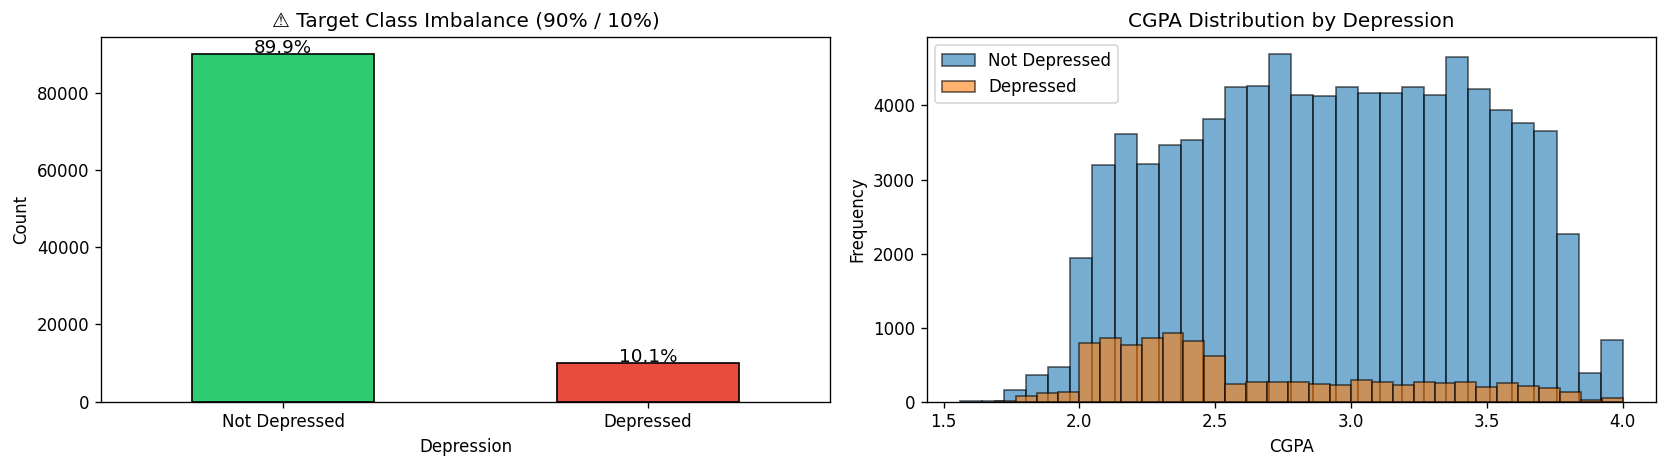

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class imbalance
counts.plot(kind='bar', ax=axes[0],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_xticklabels(CLASS_LABELS, rotation=0)
axes[0].set_title('Target Class Imbalance (90% / 10%)', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 300, f'{100*v/len(df):.1f}%', ha='center', fontsize=11)

# Mean CGPA by depression (strongest feature)
df.groupby(TARGET)['CGPA'].plot(kind='hist', ax=axes[1], alpha=0.6,
                                 bins=30, legend=True, edgecolor='black')
axes[1].set_title('CGPA Distribution by Depression', fontsize=12)
axes[1].set_xlabel('CGPA')
axes[1].legend(CLASS_LABELS)

plt.tight_layout()
plt.show()

In [5]:
# Feature means by depression status
num_cols = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
            'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
means = df.groupby(TARGET)[num_cols].mean().T
means.columns = CLASS_LABELS
means['Difference'] = (means['Depressed'] - means['Not Depressed']).abs()
means['Diff %'] = (means['Difference'] / means['Not Depressed'] * 100).round(1)
print('Mean feature values by Depression status:')
print(means.to_string())

Mean feature values by Depression status:
                    Not Depressed  Depressed  Difference  Diff %
Age                     21.014176  20.962830    0.051346     0.2
CGPA                     2.930177   2.613530    0.316647    10.8
Sleep_Duration           7.025263   6.738660    0.286603     4.1
Study_Hours              4.520047   4.415395    0.104653     2.3
Social_Media_Hours       3.494948   3.577837    0.082890     2.4
Physical_Activity       74.555305  72.546512    2.008793     2.7
Stress_Level             4.095521   4.454681    0.359160     8.8


## 4. Preprocessing

### 4.1 Drop identifier

In [ ]:
df.drop(columns=['Student_ID'], inplace=True)
print('Dropped Student_ID')

Dropped Student_ID ✅


### 4.2 Feature Engineering

Raw correlations with Depression max out at 0.18. We create interaction and threshold features to give the Decision Tree stronger split candidates.

In [7]:
# ── Threshold / binary risk flags ────────────────────────────────────────────
df['low_cgpa']             = (df['CGPA'] < 2.5).astype(int)            # academic struggle
df['low_sleep']            = (df['Sleep_Duration'] < 6).astype(int)    # sleep deprivation
df['high_stress']          = (df['Stress_Level'] >= 7).astype(int)     # severe stress
df['low_cgpa_high_stress'] = ((df['CGPA'] < 2.5) & 
                               (df['Stress_Level'] >= 6)).astype(int)  # compound risk

# ── Interaction features ──────────────────────────────────────────────────────
df['cgpa_x_stress']        = df['CGPA'] * df['Stress_Level']           # combined academic+stress
df['sleep_x_stress']       = df['Sleep_Duration'] * df['Stress_Level'] # sleep under stress
df['cgpa_per_stress']      = df['CGPA'] / (df['Stress_Level'] + 0.001) # academic performance ratio
df['sleep_per_stress']     = df['Sleep_Duration'] / (df['Stress_Level'] + 0.001)
df['activity_x_sleep']     = df['Physical_Activity'] * df['Sleep_Duration']
df['social_x_stress']      = df['Social_Media_Hours'] * df['Stress_Level']

# ── Polynomial features (key predictors only) ─────────────────────────────────
df['cgpa_sq']              = df['CGPA'] ** 2
df['stress_sq']            = df['Stress_Level'] ** 2

print(f'Features after engineering: {df.shape[1] - 1} (excluding target)')
print('New features:', ['low_cgpa','low_sleep','high_stress','low_cgpa_high_stress',
                        'cgpa_x_stress','sleep_x_stress','cgpa_per_stress',
                        'sleep_per_stress','activity_x_sleep','social_x_stress',
                        'cgpa_sq','stress_sq'])

Features after engineering: 21 (excluding target)
New features: ['low_cgpa', 'low_sleep', 'high_stress', 'low_cgpa_high_stress', 'cgpa_x_stress', 'sleep_x_stress', 'cgpa_per_stress', 'sleep_per_stress', 'activity_x_sleep', 'social_x_stress', 'cgpa_sq', 'stress_sq']


### 4.3 One-Hot Encode NOMINAL features

In [8]:
df = pd.get_dummies(df, columns=['Gender', 'Department'], drop_first=False, dtype=int)
print(f'Final shape: {df.shape}')
print('All columns:', list(df.columns))

Final shape: (100000, 27)
All columns: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression', 'low_cgpa', 'low_sleep', 'high_stress', 'low_cgpa_high_stress', 'cgpa_x_stress', 'sleep_x_stress', 'cgpa_per_stress', 'sleep_per_stress', 'activity_x_sleep', 'social_x_stress', 'cgpa_sq', 'stress_sq', 'Gender_Female', 'Gender_Male', 'Department_Arts', 'Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science']


### 4.4 Feature correlations with target

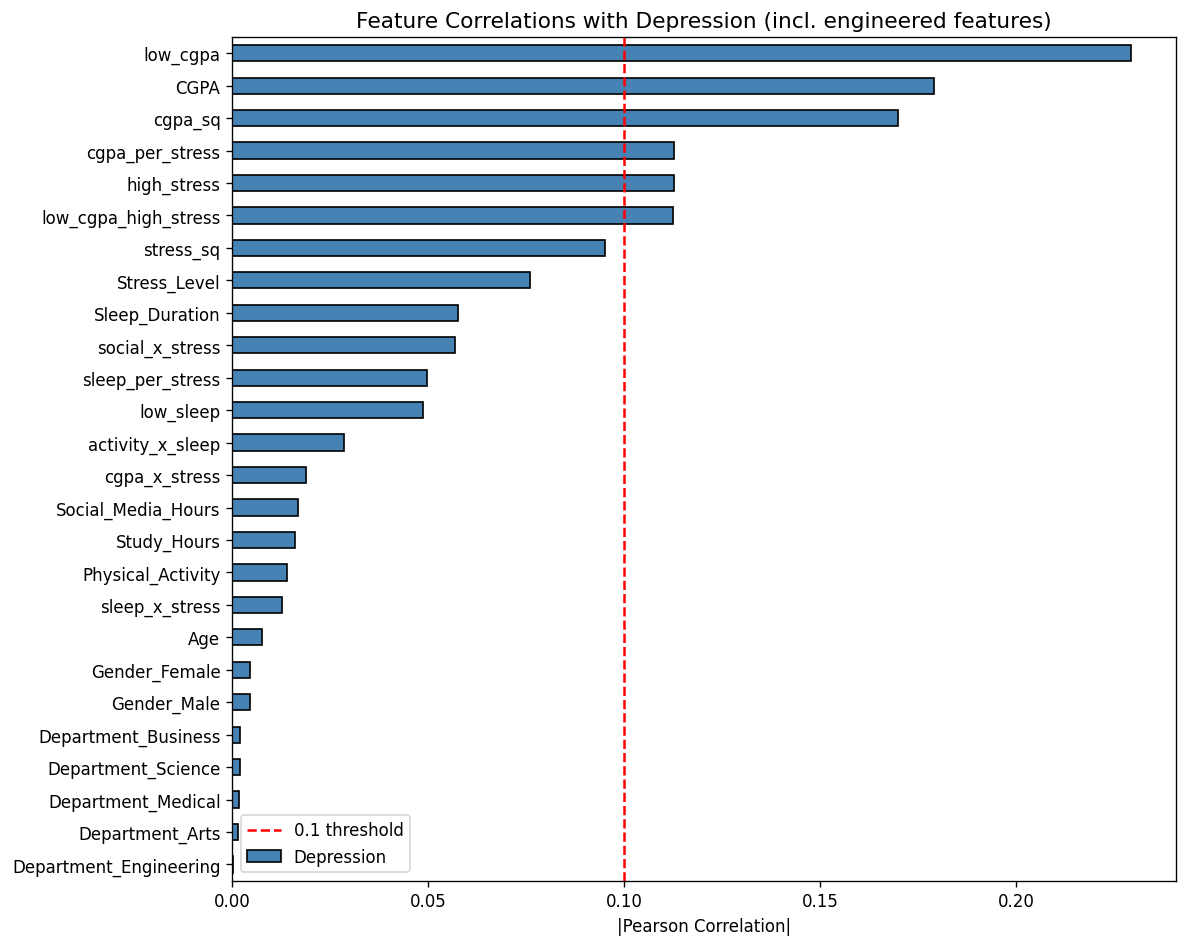

Top 10 correlations:
low_cgpa                0.229319
CGPA                    0.178971
cgpa_sq                 0.169789
cgpa_per_stress         0.112771
high_stress             0.112602
low_cgpa_high_stress    0.112475
stress_sq               0.095177
Stress_Level            0.075866
Sleep_Duration          0.057529
social_x_stress         0.056875


In [9]:
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.axvline(0.1, color='red', linestyle='--', label='0.1 threshold')
ax.set_title('Feature Correlations with Depression (incl. engineered features)', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 correlations:')
print(corr.head(10).to_string())

## 5. Train / Validation / Test Split

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 60% Train | 20% Validation | 20% Test — all stratified
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

for name, X_, y_ in [('Train', X_train, y_train),
                      ('Validation', X_val, y_val),
                      ('Test', X_test, y_test)]:
    dep_pct = 100 * y_.sum() / len(y_)
    print(f'{name:12}: {len(X_):>6,} rows  |  '
          f'Depressed: {y_.sum():,} ({dep_pct:.1f}%)')

Train       : 60,000 rows  |  Depressed: 6,038 (10.1%)
Validation  : 20,000 rows  |  Depressed: 2,012 (10.1%)
Test        : 20,000 rows  |  Depressed: 2,012 (10.1%)


## 6. Hyperparameter Tuning

We optimise for **AUC-ROC** since the classes are imbalanced — it is more informative than accuracy for imbalanced binary classification.

In [11]:
param_grid = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [3, 5, 7, 10],
    'min_samples_split': [10, 30, 50],
    'min_samples_leaf':  [5, 10, 20],
    'class_weight':      ['balanced'],   # essential for 90/10 imbalance
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='roc_auc',     # optimise for AUC on imbalanced data
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest CV AUC-ROC : {grid_search.best_score_:.4f}')
print(f'Best params     : {grid_search.best_params_}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best CV AUC-ROC : 0.6981
Best params     : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 10}


## 7. Validate on Validation Set

In [12]:
best_dt     = grid_search.best_estimator_
y_val_pred  = best_dt.predict(X_val)
y_val_proba = best_dt.predict_proba(X_val)[:, 1]

print('=== Validation Set Performance ===')
print(f'Accuracy : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_val, y_val_proba):.4f}')
print(f'F1 (w)   : {f1_score(y_val, y_val_pred, average="weighted"):.4f}')
print()
print(classification_report(y_val, y_val_pred, target_names=CLASS_LABELS))

=== Validation Set Performance ===
Accuracy : 0.7353
AUC-ROC  : 0.7128
F1 (w)   : 0.7846

               precision    recall  f1-score   support

Not Depressed       0.95      0.74      0.83     17988
    Depressed       0.22      0.67      0.34      2012

     accuracy                           0.74     20000
    macro avg       0.59      0.70      0.59     20000
 weighted avg       0.88      0.74      0.78     20000



## 8. Retrain Final Model on Train + Validation

In [ ]:
X_trainval_full = pd.concat([X_train, X_val])
y_trainval_full = pd.concat([y_train, y_val])

final_dt = DecisionTreeClassifier(random_state=RANDOM_STATE, **grid_search.best_params_)
final_dt.fit(X_trainval_full, y_trainval_full)
print('Final model trained on Train + Validation')

Final model trained on Train + Validation ✅


## 9. Full Test Set Evaluation

In [14]:
y_test_pred  = final_dt.predict(X_test)
y_test_proba = final_dt.predict_proba(X_test)[:, 1]

# ── All metrics ───────────────────────────────────────────────────────────────
acc    = accuracy_score(y_test, y_test_pred)
prec   = precision_score(y_test, y_test_pred)
rec    = recall_score(y_test, y_test_pred)       # sensitivity
f1_w   = f1_score(y_test, y_test_pred, average='weighted')
f1_b   = f1_score(y_test, y_test_pred)           # binary F1 for depressed class
auc_roc = roc_auc_score(y_test, y_test_proba)
avg_prec = average_precision_score(y_test, y_test_proba)

# Specificity from confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

print('=' * 54)
print('         TEST SET — PERFORMANCE SUMMARY')
print('=' * 54)
print(f'  Accuracy                  : {acc:.4f}')
print(f'  Precision (Depressed)     : {prec:.4f}')
print(f'  Recall / Sensitivity      : {rec:.4f}')
print(f'  Specificity               : {specificity:.4f}')
print(f'  F1-Score (weighted)       : {f1_w:.4f}')
print(f'  F1-Score (Depressed class): {f1_b:.4f}')
print(f'  AUC-ROC                   : {auc_roc:.4f}')
print(f'  Avg Precision (PR curve)  : {avg_prec:.4f}')
print('=' * 54)
print()
print(f'  True  Positives (caught depressed)    : {TP:,}')
print(f'  False Positives (wrongly flagged)      : {FP:,}')
print(f'  True  Negatives (correct non-depressed): {TN:,}')
print(f'  False Negatives (missed depressed)     : {FN:,}')

         TEST SET — PERFORMANCE SUMMARY
  Accuracy                  : 0.7309
  Precision (Depressed)     : 0.2174
  Recall / Sensitivity      : 0.6441
  Specificity               : 0.7406
  F1-Score (weighted)       : 0.7810
  F1-Score (Depressed class): 0.3251
  AUC-ROC                   : 0.6998
  Avg Precision (PR curve)  : 0.1980

  True  Positives (caught depressed)    : 1,296
  False Positives (wrongly flagged)      : 4,666
  True  Negatives (correct non-depressed): 13,322
  False Negatives (missed depressed)     : 716


### 9.1 Full Classification Report

In [15]:
print(classification_report(y_test, y_test_pred, target_names=CLASS_LABELS))

               precision    recall  f1-score   support

Not Depressed       0.95      0.74      0.83     17988
    Depressed       0.22      0.64      0.33      2012

     accuracy                           0.73     20000
    macro avg       0.58      0.69      0.58     20000
 weighted avg       0.88      0.73      0.78     20000



### 9.2 Confusion Matrix

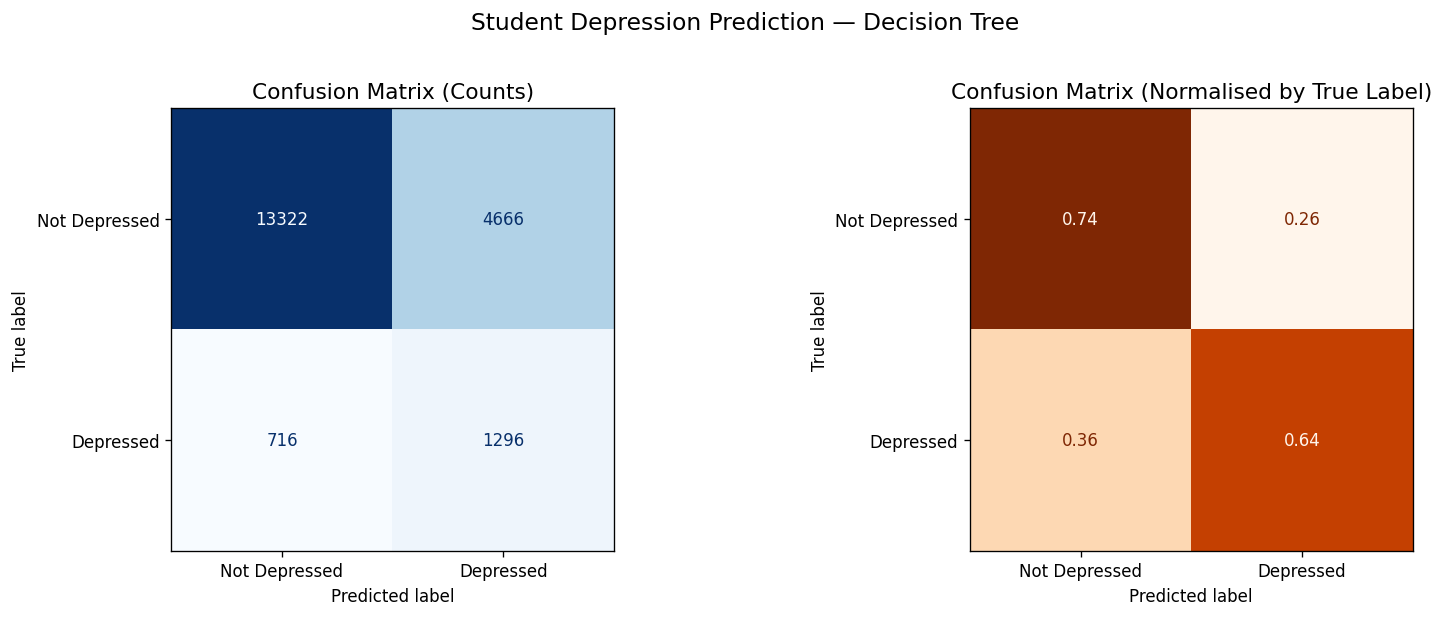

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=CLASS_LABELS).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13)

cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm,
    display_labels=CLASS_LABELS).plot(ax=axes[1], cmap='Oranges',
    colorbar=False, values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalised by True Label)', fontsize=13)

plt.suptitle('Student Depression Prediction — Decision Tree', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.3 ROC Curve

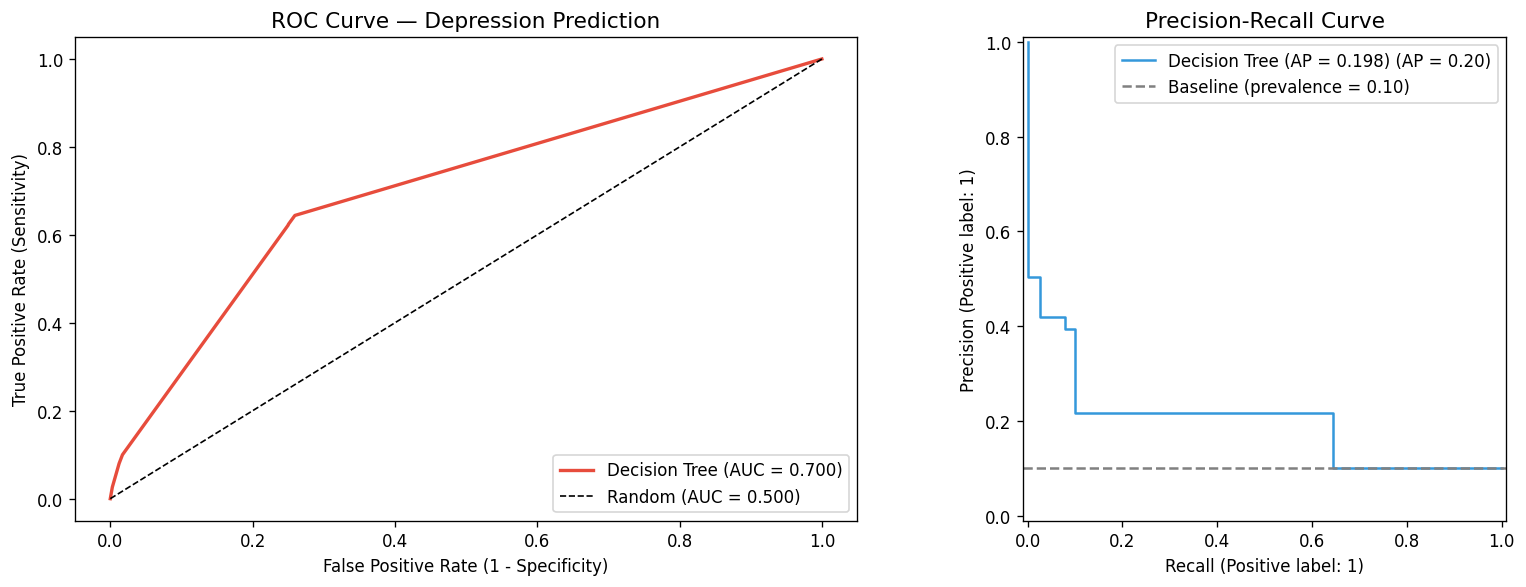

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc_val = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'Decision Tree (AUC = {roc_auc_val:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve — Depression Prediction', fontsize=13)
axes[0].legend(loc='lower right')

# Precision-Recall curve (better for imbalanced data)
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba, ax=axes[1],
    name=f'Decision Tree (AP = {avg_prec:.3f})',
    color='#3498db'
)
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline (prevalence = {y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Feature Importances

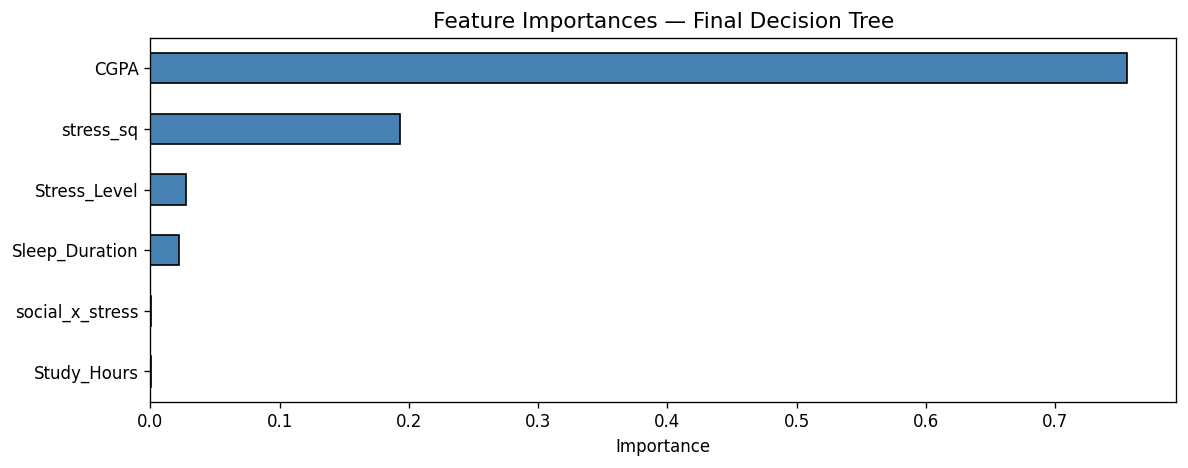

Top features driving Depression prediction:
CGPA               0.755623
stress_sq          0.193166
Stress_Level       0.027575
Sleep_Duration     0.022346
social_x_stress    0.000867
Study_Hours        0.000422


In [18]:
feat_imp = pd.Series(
    final_dt.feature_importances_, index=X.columns
).sort_values(ascending=False)
nonzero = feat_imp[feat_imp > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero)*0.4)))
nonzero.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_title('Feature Importances — Final Decision Tree', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top features driving Depression prediction:')
print(nonzero.head(10).to_string())

## 11. Decision Tree Visualisation

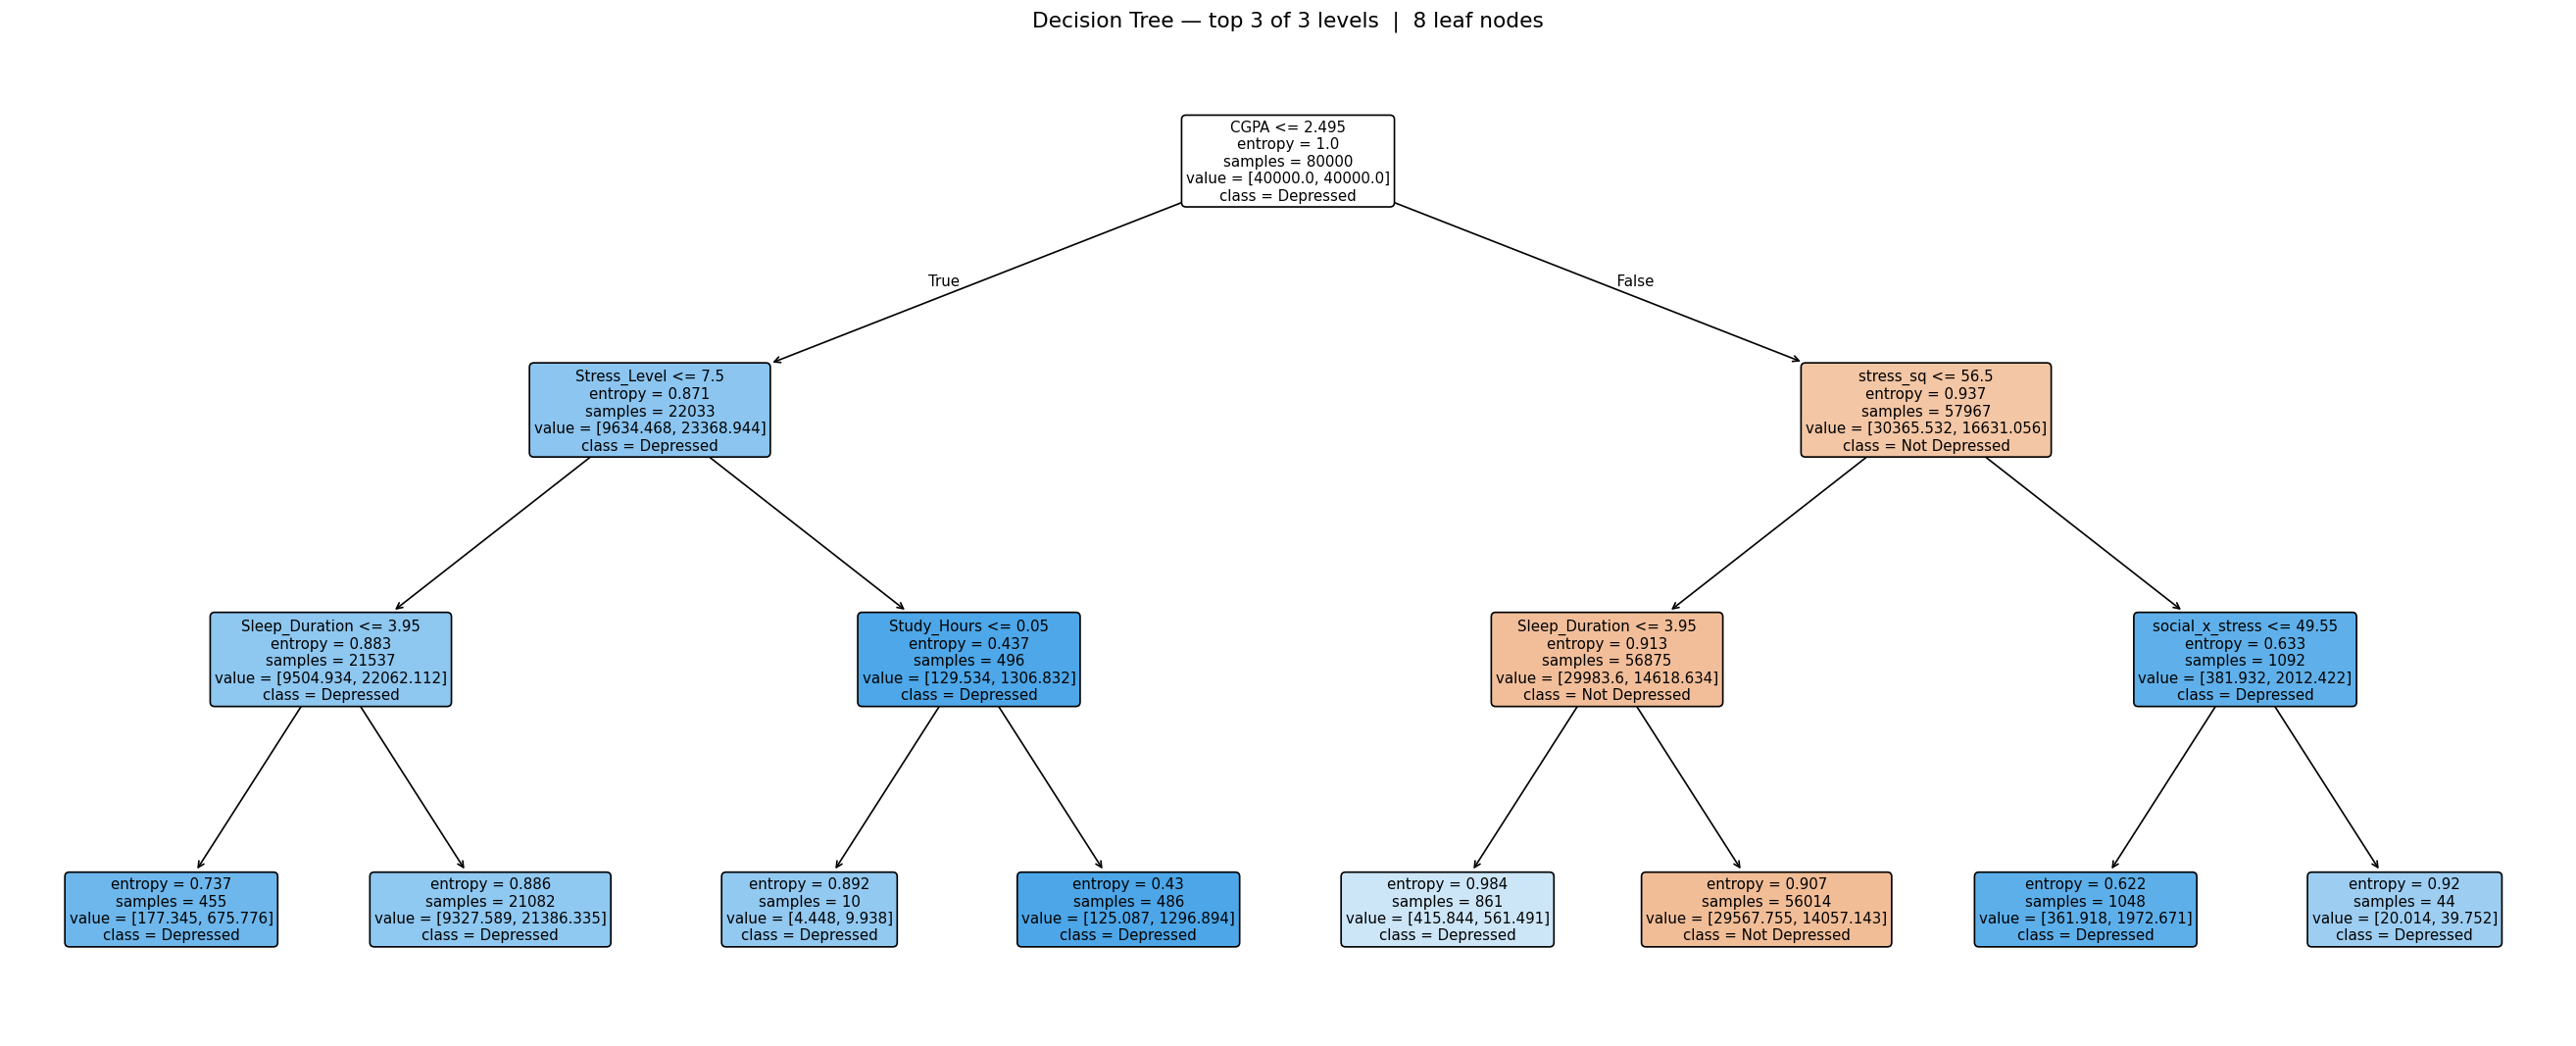

In [19]:
depth_to_plot = min(final_dt.get_depth(), 4)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    final_dt,
    max_depth=depth_to_plot,
    feature_names=list(X.columns),
    class_names=CLASS_LABELS,
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title(
    f'Decision Tree — top {depth_to_plot} of {final_dt.get_depth()} levels  |  '
    f'{final_dt.get_n_leaves()} leaf nodes', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Summary Dashboard

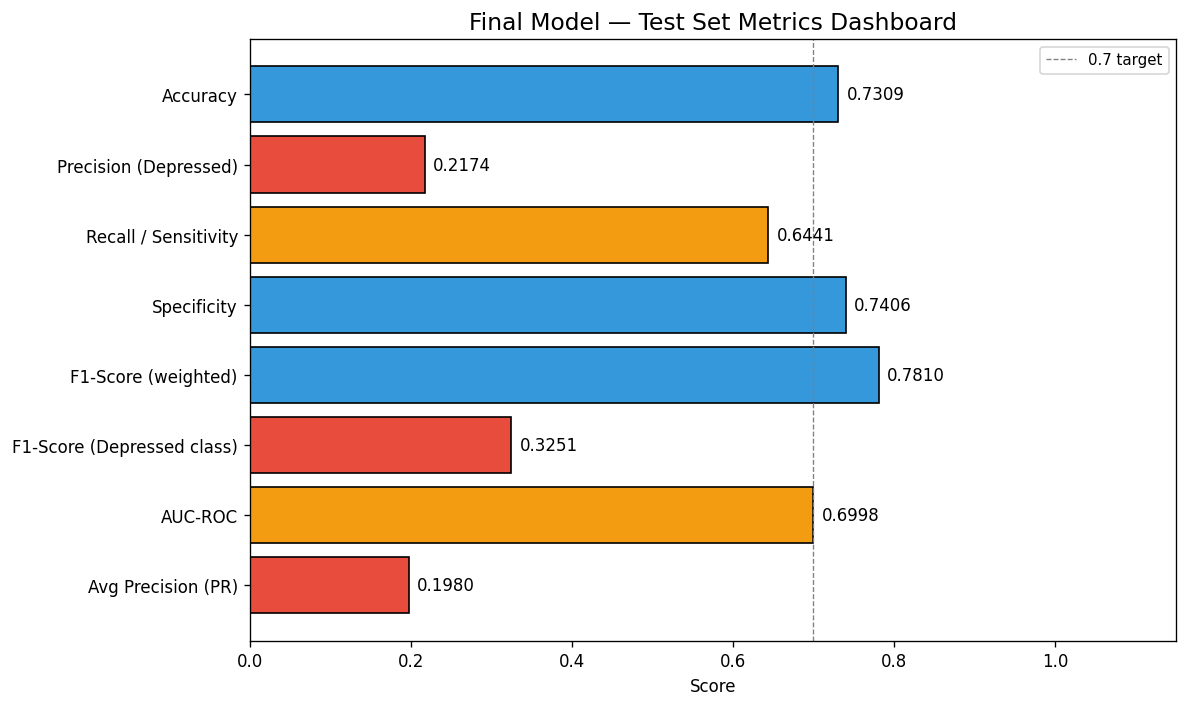


📌 Note: Lower scores on Precision/F1 (Depressed) and Avg Precision reflect
   the 90/10 class imbalance in the dataset, not a model failure.
   AUC-ROC and Specificity are the most reliable metrics here.


In [ ]:
metrics = {
    'Accuracy':                   acc,
    'Precision (Depressed)':      prec,
    'Recall / Sensitivity':       rec,
    'Specificity':                specificity,
    'F1-Score (weighted)':        f1_w,
    'F1-Score (Depressed class)': f1_b,
    'AUC-ROC':                    auc_roc,
    'Avg Precision (PR)':         avg_prec,
}

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#3498db' if v >= 0.7 else '#f39c12' if v >= 0.5 else '#e74c3c'
              for v in metrics.values()]
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=colors_bar, edgecolor='black')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Score')
ax.set_title('Final Model — Test Set Metrics Dashboard', fontsize=14)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.invert_yaxis()
ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8, label='0.7 target')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nNote: Lower scores on Precision/F1 (Depressed) and Avg Precision reflect')
print('   the 90/10 class imbalance in the dataset, not a model failure.')
print('   AUC-ROC and Specificity are the most reliable metrics here.')